<a href="https://colab.research.google.com/github/gguex/ISH_ressources_cours_ML/blob/main/TP02_regression_generalisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning (Lettres) TP 2 : Régression et généralisation

Dans ce TP, nous allons voir comment :

* Ajuster une régression multiple "à la main" (avec `numpy`)
* Ajuster des modèles linéaires avec `scikit-learn`
* Sélectionner un hyperparamètre (un modèle) par cross-validation, puis estimer son erreur de généralisation sur un jeu de test réservé.

Il y aura également un **exercice**, qui vous demandera d'effectuer vous-même une recherche d'hyperparamètre avec une régression Ridge, sur un nouveau jeu de données.

Pour ce TP, il nous faudra les librairies, modules et objets suivants :

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# Pour les modèles linéaires
from sklearn.linear_model import LinearRegression, Lasso, Ridge
# Pour séparer le jeu de données, définir les folds et chercher les hyperparamètres
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
# Pour les prétraitements (valeurs manquantes, standardisation) et les enchaîner avec un modèle
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

---

## Chargement et traitement des données

Comme au TP 1, les données de ce TP se trouvent dans le dossier `data/TP2/` (dans `Mon Drive/Colab Notebooks` sur Colab, à côté du notebook en local). La cellule suivante choisit le chemin selon l'environnement.

In [2]:
# Connexion à Google Drive sur Colab ; dossier local sinon
try:
    from google.colab import drive
except ImportError:
    data_path = Path("data") / "TP2"
else:
    drive.mount("/content/drive")
    data_path = Path("/content/drive/MyDrive/Colab Notebooks/data/TP2")

Mounted at /content/drive


Chargeons le jeu de données "cancer_reg.csv" (https://github.com/Arnab777as3uj/STAT6021-Cancer-Prediction-Project). Ce jeu de données contient de nombreuses variables concernant des localités aux États-Unis, avec en particulier la variable **TARGET_deathRate** contenant la mortalité moyenne par année (sur 100'000 habitants) due au cancer.

In [3]:
file_path = data_path / "cancer_reg.csv"
# L'encodage du fichier est "latin-1"
data = pd.read_csv(file_path, encoding="latin-1")
data.head()

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,binnedInc,MedianAge,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
0,1397.0,469,164.9,489.8,61898,260131,11.2,499.748204,"(61494.5, 125635]",39.3,...,NaN,41.6,32.9,14.0,81.780529,2.594728,4.821857,1.843479,52.856076,6.118831
1,173.0,70,161.3,411.6,48127,43269,18.6,23.111234,"(48021.6, 51046.4]",33.0,...,53.8,43.6,31.1,15.3,89.228509,0.969102,2.246233,3.741352,45.372500,4.333096
2,102.0,50,174.7,349.7,49348,21026,14.6,47.560164,"(48021.6, 51046.4]",45.0,...,43.5,34.9,42.1,21.1,90.922190,0.739673,0.465898,2.747358,54.444868,3.729488
3,427.0,202,194.8,430.4,44243,75882,17.1,342.637253,"(42724.4, 45201]",42.8,...,40.3,35.0,45.3,25.0,91.744686,0.782626,1.161359,1.362643,51.021514,4.603841
4,57.0,26,144.4,350.1,49955,10321,12.5,0.000000,"(48021.6, 51046.4]",48.3,...,43.9,35.1,44.0,22.7,94.104024,0.270192,0.665830,0.492135,54.027460,6.796657


Remarquons qu'il n'y a que des variables numériques, mis à part **binnedInc** (un intervalle) et **Geography** (nom de la localité) (voir `data.dtypes`). Les variables **incidenceRate**, **avgAnnCount**, **avgDeathsPerYear**, **popEst2015** sont des variables qui ont servi à la construction de la variable dépendante ou qui ne sont pas pertinentes. Nous allons enlever toutes ces variables :

In [4]:
data = data.drop(columns=["binnedInc", "Geography", "incidenceRate", "avgAnnCount",
                          "avgDeathsPerYear", "popEst2015"])
data.head()

,TARGET_deathRate,medIncome,povertyPercent,studyPerCap,MedianAge,MedianAgeMale,MedianAgeFemale,AvgHouseholdSize,PercentMarried,PctNoHS18_24,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
0,164.9,61898,11.2,499.748204,39.3,36.9,41.7,2.54,52.5,11.5,...,NaN,41.6,32.9,14.0,81.780529,2.594728,4.821857,1.843479,52.856076,6.118831
1,161.3,48127,18.6,23.111234,33.0,32.2,33.7,2.34,44.5,6.1,...,53.8,43.6,31.1,15.3,89.228509,0.969102,2.246233,3.741352,45.372500,4.333096
2,174.7,49348,14.6,47.560164,45.0,44.0,45.8,2.62,54.2,24.0,...,43.5,34.9,42.1,21.1,90.922190,0.739673,0.465898,2.747358,54.444868,3.729488
3,194.8,44243,17.1,342.637253,42.8,42.2,43.4,2.52,52.7,20.2,...,40.3,35.0,45.3,25.0,91.744686,0.782626,1.161359,1.362643,51.021514,4.603841
4,144.4,49955,12.5,0.000000,48.3,47.8,48.9,2.34,57.8,14.9,...,43.9,35.1,44.0,22.7,94.104024,0.270192,0.665830,0.492135,54.027460,6.796657


Notre jeu de données possède des valeurs manquantes (`NaN`) dans quelques variables :

In [5]:
missing = data.isna().sum()
missing[missing > 0]

,0
PctSomeCol18_24,2285
PctEmployed16_Over,152
PctPrivateCoverageAlone,609


Nous les remplacerons par la moyenne de la variable concernée. Mais attention : comme vu au cours, cette moyenne doit être calculée sur les données d'**entraînement** uniquement, puis appliquée telle quelle aux données de validation ou de test. Nous devons donc d'abord séparer notre jeu de données.

Commençons par isoler la variable dépendante des autres variables :

In [6]:
outputs = data["TARGET_deathRate"]
inputs = data.drop(columns=["TARGET_deathRate"])

## Séparation développement / test

On scinde aléatoirement le jeu de données en deux, avec d'un côté le jeu de **développement** (qui servira à l'entraînement et à la validation), et de l'autre le jeu de **test**, mis de côté jusqu'à la fin. La taille du jeu de test est posée à 20%. Nous utilisons pour cela la fonction `train_test_split` de `scikit-learn`. L'argument `random_state` fixe le tirage aléatoire, afin de retrouver les mêmes résultats à chaque exécution.

In [7]:
inputs_dev, inputs_test, outputs_dev, outputs_test = \
    train_test_split(inputs, outputs, test_size=0.2, random_state=42)
print(f"Développement : {inputs_dev.shape[0]} individus, test : {inputs_test.shape[0]} individus")

Développement : 2437 individus, test : 610 individus


Nous pouvons maintenant remplacer les valeurs manquantes par les moyennes, calculées sur le jeu de développement. Les **mêmes moyennes** servent pour le jeu de test : celui-ci ne doit servir à calculer aucune quantité. Nous gardons `inputs_dev` (avec ses valeurs manquantes) pour la suite du TP, où chaque pli de cross-validation calculera ses propres moyennes.

In [8]:
dev_means = inputs_dev.mean()
inputs_dev_filled = inputs_dev.fillna(dev_means)
inputs_test_filled = inputs_test.fillna(dev_means)
dev_means

,0
medIncome,47081.780468
povertyPercent,16.841034
studyPerCap,155.832261
MedianAge,45.620189
MedianAgeMale,39.591957
MedianAgeFemale,42.160812
AvgHouseholdSize,2.481925
PercentMarried,51.825892
PctNoHS18_24,18.255478
PctHS18_24,35.118178


---

## Régression linéaire avec `numpy`

Nous allons faire ici une régression linéaire "à la main", à l'aide de la librairie `numpy`, sur le jeu de développement. Ainsi, nous pourrons comparer ces résultats avec ceux obtenus grâce à `scikit-learn`. Tout d'abord, on transforme nos entrées et sorties en arrays :

In [9]:
inputs_a = inputs_dev_filled.to_numpy()
outputs_a = outputs_dev.to_numpy()
n_row, n_col = inputs_a.shape

Pour que nous puissions calculer l'intercept $w_0$, nous allons devoir ajouter une colonne de $1$ à nos entrées :

In [10]:
vec_of_ones = np.ones([n_row, 1])
x_matrix = np.concatenate([vec_of_ones, inputs_a], axis=1)
x_matrix

array([[1.00000000e+00, 4.73630000e+04, 1.38000000e+01, ...,
        8.79130588e-01, 5.09495449e+01, 6.32966083e+00],
       [1.00000000e+00, 7.72220000e+04, 6.80000000e+00, ...,
        1.18612237e-01, 6.45321557e+01, 5.14813016e+00],
       [1.00000000e+00, 8.06500000e+04, 7.50000000e+00, ...,
        4.50617284e-01, 6.23444812e+01, 5.62746201e+00],
       ...,
       [1.00000000e+00, 4.97900000e+04, 1.26000000e+01, ...,
        6.51014968e-01, 4.77074118e+01, 4.93728847e+00],
       [1.00000000e+00, 5.08860000e+04, 1.04000000e+01, ...,
        1.46252285e-01, 6.24369748e+01, 8.95196507e+00],
       [1.00000000e+00, 4.55560000e+04, 1.38000000e+01, ...,
        4.06235551e-01, 4.72017573e+01, 4.82368596e+00]])

Effectuons maintenant la formule de régression $\textbf{w} = (\textbf{X}^\top \textbf{X})^{-1}\textbf{X}^\top \textbf{y}$ pour trouver les coefficients $\textbf{w}$ :

In [11]:
coef = np.linalg.inv(x_matrix.T @ x_matrix) @ x_matrix.T @ outputs_a
coef

array([ 2.42488792e+02,  2.46613793e-04,  2.15245062e-01,  8.09183577e-04,
        4.08901113e-04, -6.48129387e-01, -1.19062195e-01, -1.47927193e+00,
        1.23025677e+00, -2.08357399e-01,  3.14723381e-01,  3.67446537e-02,
       -5.24084646e-02,  4.56853686e-01, -1.69957950e+00, -4.78414196e-01,
        4.68569624e-01, -1.57303516e-01,  6.08523356e-02,  4.70691781e-01,
       -2.67786256e-01,  9.26194621e-01, -1.22782023e-01, -7.82346966e-02,
       -2.70677223e-01, -1.31363721e+00, -1.68801969e+00, -1.42397411e+00])

Calculons maintenant les prédictions et la $MSE$ :

In [12]:
outputs_pred = x_matrix @ coef
mse = np.mean((outputs_pred - outputs_a)**2)
print(f"MSE = {mse:.2f}")

MSE = 452.59


Nous allons comparer ces résultats avec ceux obtenus avec `scikit-learn`.

---

## Régression linéaire avec `scikit-learn`

Le fonctionnement usuel des méthodes dans `scikit-learn` se passe selon les étapes suivantes :

* On crée une instance de la classe de la méthode désirée (ici `LinearRegression`).
* On fait appel à la méthode `fit` de l'objet, en lui passant nos données. Cette méthode entraîne le modèle et trouve les paramètres optimaux.
* L'instance contient maintenant toutes les informations relatives au modèle entraîné, que l'on peut extraire. La méthode `predict` permet de calculer des prédictions.

L'entraînement se fait donc de la manière suivante :

In [13]:
linear_reg = LinearRegression()
linear_reg.fit(inputs_dev_filled, outputs_dev)

LinearRegression()

Puis on peut extraire l'intercept :

In [14]:
linear_reg.intercept_

np.float64(242.4887920817506)

ou les coefficients :

In [15]:
linear_reg.coef_

array([ 2.46613793e-04,  2.15245062e-01,  8.09183577e-04,  4.08901113e-04,
       -6.48129387e-01, -1.19062195e-01, -1.47927193e+00,  1.23025677e+00,
       -2.08357399e-01,  3.14723381e-01,  3.67446537e-02, -5.24084646e-02,
        4.56853686e-01, -1.69957950e+00, -4.78414196e-01,  4.68569624e-01,
       -1.57303516e-01,  6.08523356e-02,  4.70691781e-01, -2.67786256e-01,
        9.26194621e-01, -1.22782023e-01, -7.82346966e-02, -2.70677223e-01,
       -1.31363721e+00, -1.68801969e+00, -1.42397411e+00])

Comparons avec le résultat obtenu avec `numpy` :

In [16]:
coef - np.append(linear_reg.intercept_, linear_reg.coef_)

array([-4.99312591e-10, -6.03575349e-16, -9.43412015e-14, -3.52148866e-15,
       -1.01606007e-15, -2.62856403e-12,  3.62469776e-12,  2.36346498e-11,
       -2.48956411e-12,  4.80920859e-13,  2.50799381e-13, -2.71269118e-13,
       -4.00394995e-13,  7.54118989e-13,  1.02251541e-12,  2.91261459e-12,
        2.35728104e-12,  1.87203031e-12,  2.53130850e-13, -6.64968081e-13,
        1.56791247e-12,  3.08975068e-13,  7.21853133e-13,  4.92259011e-13,
        9.92317339e-13,  1.20192745e-12,  1.96087591e-12,  7.72271136e-13])

On voit que les résultats sont identiques. Qu'en est-il des prédictions et de la $MSE$ ?

In [17]:
sk_outputs_pred = linear_reg.predict(inputs_dev_filled)
sk_mse = np.mean((sk_outputs_pred - outputs_dev)**2)
print(f"MSE numpy = {mse}, MSE scikit-learn = {sk_mse}")

MSE numpy = 452.5855046042304, MSE scikit-learn = 452.58550460423044


L'erreur est identique et on peut être rassuré sur les capacités de `scikit-learn` ! Pour plus d'informations sur `LinearRegression`, voir https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html.

Notons que cette $MSE$ est calculée sur les données qui ont servi à l'entraînement : elle ne nous dit rien sur la capacité du modèle à **généraliser** à de nouvelles localités. Nous y reviendrons.

---

## La sélection de l'hyperparamètre d'une régression *Lasso* par cross-validation

Dans les parties précédentes, nous avons utilisé toutes les variables du jeu de données. Ici, grâce à une régression régularisée de type *Lasso* (L1), nous allons voir si certaines variables peuvent être omises. Pour cela, nous allons chercher un hyperparamètre $\lambda$ optimal par cross-validation sur le jeu de développement, puis évaluer le modèle retenu sur le jeu de test. Dans `scikit-learn`, $\lambda$ s'appelle `alpha`.

Deux prétraitements sont nécessaires à chaque entraînement :

* remplacer les valeurs manquantes par la moyenne de la variable ;
* **standardiser** les variables (les ramener à une moyenne de 0 et un écart-type de 1). C'est important pour Lasso : la pénalité porte sur les coefficients, et ceux-ci dépendent de l'échelle des variables. Sans standardisation, une variable mesurée en milliers serait pénalisée différemment d'une variable mesurée en pourcents.

Comme vu au cours, les moyennes et écarts-types sont calculés sur le pli d'entraînement, puis appliqués au pli de validation.

Posons les valeurs de $\lambda$ qui vont être testées (50 valeurs entre 0.001 et 1, la valeur 0 ne fonctionne pas bien avec le Lasso de `scikit-learn`), ainsi que le nombre de folds $k$. L'objet `KFold` tire aléatoirement l'attribution des individus aux folds ; sa méthode `split` nous donnera, pour chaque fold, les indices des individus d'entraînement et de validation.

In [18]:
hyp_lambdas = np.linspace(0.001, 1, 50)
k = 5
folds = KFold(n_splits=k, shuffle=True, random_state=42)

Passons maintenant aux boucles formant le cœur de la cross-validation. La boucle extérieure va tester toutes les valeurs de $\lambda$, et pour chaque valeur, la boucle intérieure va entraîner et valider un modèle selon les folds. Les résultats finaux de cette double boucle sont deux listes contenant les valeurs moyennes de $MSE_\text{train}$ et $MSE_\text{valid}$ pour chaque $\lambda$.

In [19]:
# Pour stocker la moyenne du mse pour chaque hyperparamètre
train_mse_means, val_mse_means = [], []

# Boucle sur les lambdas
for hyp_lambda in hyp_lambdas:

    # Pour stocker la valeur du mse sur chaque fold
    train_mses, val_mses = [], []

    # Boucle sur les folds
    for indices_train, indices_val in folds.split(inputs_dev):

        # On sépare le jeu de développement en 2 groupes : entraînement - validation
        inputs_train = inputs_dev.iloc[indices_train]
        inputs_val = inputs_dev.iloc[indices_val]
        outputs_train = outputs_dev.iloc[indices_train]
        outputs_val = outputs_dev.iloc[indices_val]

        # Prétraitements : les moyennes et écarts-types viennent du groupe d'entraînement
        means = inputs_train.mean()
        inputs_train = inputs_train.fillna(means)
        inputs_val = inputs_val.fillna(means)
        stds = inputs_train.std(ddof=0)  # ddof=0 : même formule que StandardScaler
        inputs_train = (inputs_train - means) / stds
        inputs_val = (inputs_val - means) / stds

        # On entraîne le modèle ("alpha" est le paramètre de régularisation)
        lasso_reg = Lasso(alpha=hyp_lambda)
        lasso_reg.fit(inputs_train, outputs_train)

        # On calcule la train_mse et val_mse
        train_mse = np.mean((lasso_reg.predict(inputs_train) - outputs_train)**2)
        val_mse = np.mean((lasso_reg.predict(inputs_val) - outputs_val)**2)

        # On sauve les valeurs
        train_mses.append(train_mse)
        val_mses.append(val_mse)

    # On sauve les moyennes sur les folds
    train_mse_means.append(np.mean(train_mses))
    val_mse_means.append(np.mean(val_mses))

In [20]:
np.round(val_mse_means, 1)

array([472.1, 471.2, 470.6, 470.1, 469.8, 469.5, 469.3, 469.3, 469.6,
       469.9, 470.3, 470.6, 470.9, 471.3, 471.6, 471.8, 471.9, 471.9,
       472. , 472. , 472.1, 472.1, 472.2, 472.3, 472.5, 472.6, 472.8,
       473. , 473.2, 473.4, 473.6, 473.8, 474. , 474.3, 474.6, 474.9,
       475.2, 475.5, 475.8, 476.2, 476.5, 476.9, 477.3, 477.7, 478.1,
       478.5, 478.9, 479.3, 479.7, 480. ])

Observons comment varient $MSE_\text{train}$ et $MSE_\text{valid}$ en fonction de $\lambda$ :

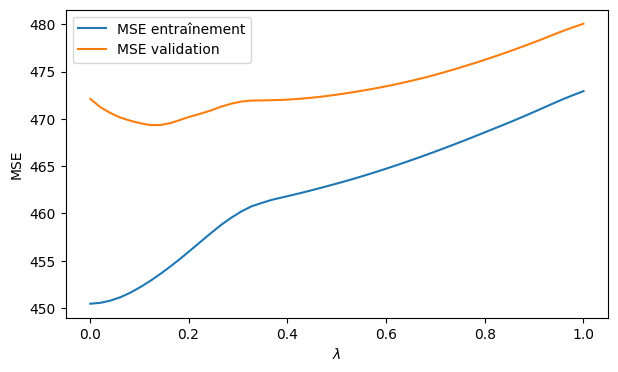

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hyp_lambdas, train_mse_means, label="MSE entraînement")
ax.plot(hyp_lambdas, val_mse_means, label="MSE validation")
ax.set(xlabel="$\\lambda$", ylabel="MSE")
ax.legend()
plt.show()

L'erreur d'entraînement augmente avec $\lambda$ (le modèle est de plus en plus contraint), tandis que l'erreur de validation passe par un minimum. On trouve la valeur optimale de l'hyperparamètre $\lambda$ avec `np.argmin`, qui donne l'indice du minimum :

In [22]:
index_opt = np.argmin(val_mse_means)
opt_hyp_lambda = hyp_lambdas[index_opt]
print(f"La valeur optimale de lambda est : {opt_hyp_lambda:.3f}")

La valeur optimale de lambda est : 0.123


Pour calculer l'erreur de généralisation, il faudrait maintenant réentraîner le modèle sur tout le jeu de développement, en recalculant les prétraitements sur ce jeu, puis les appliquer au jeu de test. Ces prétraitements répétés sont fastidieux et sources d'erreurs. Voyons d'abord comment `scikit-learn` permet de faire tout cela de manière beaucoup plus compacte.

---

## Prétraitements et sélection d'hyperparamètre avec `scikit-learn`

`scikit-learn` permet d'enchaîner les prétraitements et le modèle dans une **pipeline** : `SimpleImputer` remplace les valeurs manquantes par la moyenne, `StandardScaler` standardise les variables, puis `Lasso` est entraîné. Lorsqu'on appelle `fit`, chaque étape est ajustée sur les données d'entraînement uniquement, et `predict` applique les mêmes transformations aux nouvelles données. Nous n'avons donc plus à gérer les moyennes et écarts-types nous-mêmes. Pour plus de détails, voir https://scikit-learn.org/stable/modules/compose.html.

In [23]:
lasso_pipeline = make_pipeline(SimpleImputer(strategy="mean"),
                               StandardScaler(),
                               Lasso())
lasso_pipeline

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('standardscaler', StandardScaler()), ('lasso', Lasso())])

La classe `GridSearchCV` effectue ensuite la recherche d'hyperparamètres par cross-validation (voir https://scikit-learn.org/stable/modules/grid_search.html). Les valeurs à tester sont données dans un dictionnaire : le nom `lasso__alpha` désigne le paramètre `alpha` de l'étape `lasso` de la pipeline. Le score `"neg_mean_squared_error"` est l'opposé de la $MSE$ : `scikit-learn` cherche toujours à **maximiser** un score, d'où le signe négatif. Nous réutilisons les mêmes folds que précédemment.

In [24]:
param_grid = {"lasso__alpha": hyp_lambdas}
grid_search = GridSearchCV(lasso_pipeline,
                           param_grid,
                           scoring="neg_mean_squared_error",
                           cv=folds,
                           return_train_score=True)
grid_search.fit(inputs_dev, outputs_dev)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('simpleimputer', SimpleImputer()),
                                       ('standardscaler', StandardScaler()),
                                       ('lasso', Lasso())]),
             param_grid={'lasso__alpha': array([0.001     , 0.02138776, 0.04177551, 0.06216327, 0.08255102,
       0.10293878, 0.12332653, 0.14371429, 0.16410204, 0.1844898 ,
       0.20487755, 0.22526531, 0.24565306,...
       0.4087551 , 0.42914286, 0.44953061, 0.46991837, 0.49030612,
       0.51069388, 0.53108163, 0.55146939, 0.57185714, 0.5922449 ,
       0.61263265, 0.63302041, 0.65340816, 0.67379592, 0.69418367,
       0.71457143, 0.73495918, 0.75534694, 0.77573469, 0.79612245,
       0.8165102 , 0.83689796, 0.85728571, 0.87767347, 0.89806122,
       0.91844898, 0.93883673, 0.95922449, 0.97961224, 1.        ])},
             return_train_score=True, scoring='neg_mean_squared_error')

{'lasso__alpha': np.float64(0.12332653061224491)}


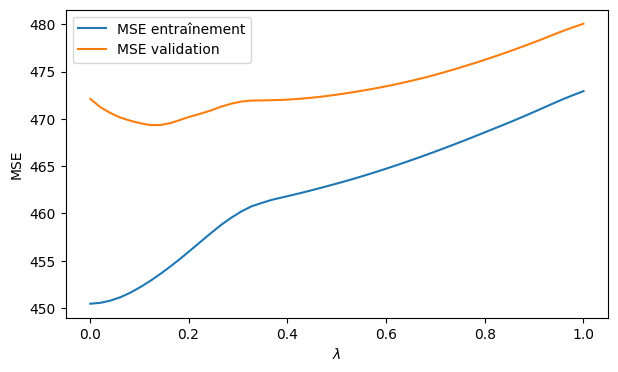

In [25]:
# Le meilleur hyperparamètre
print(grid_search.best_params_)
# Les scores moyens sur les folds (on remet le signe de la MSE)
train_score = -grid_search.cv_results_["mean_train_score"]
val_score = -grid_search.cv_results_["mean_test_score"]
# Le graphique
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hyp_lambdas, train_score, label="MSE entraînement")
ax.plot(hyp_lambdas, val_score, label="MSE validation")
ax.set(xlabel="$\\lambda$", ylabel="MSE")
ax.legend()
plt.show()

On retrouve exactement les courbes et le $\lambda$ optimal obtenus avec nos boucles.

---

## Erreur de généralisation sur le jeu de test

`GridSearchCV` a déjà réentraîné la meilleure pipeline sur tout le jeu de développement : elle est disponible dans `best_estimator_`. Nous pouvons maintenant calculer, **une seule fois**, l'erreur sur le jeu de test :

In [26]:
test_mse_lasso = np.mean((grid_search.best_estimator_.predict(inputs_test) - outputs_test)**2)
print(f"MSE test Lasso = {test_mse_lasso:.2f}")

MSE test Lasso = 495.03


Comparons-la à la régression linéaire "classique", avec les mêmes prétraitements, ainsi qu'à une référence naïve : prédire pour tout le monde la moyenne de la variable dépendante (calculée sur le jeu de développement).

In [27]:
# Régression linéaire avec les mêmes prétraitements
linear_pipeline = make_pipeline(SimpleImputer(strategy="mean"),
                                StandardScaler(),
                                LinearRegression())
linear_pipeline.fit(inputs_dev, outputs_dev)
test_mse_linear = np.mean((linear_pipeline.predict(inputs_test) - outputs_test)**2)

# Référence naïve : la moyenne
test_mse_mean = np.mean((outputs_dev.mean() - outputs_test)**2)

print(f"MSE test : moyenne = {test_mse_mean:.1f}, régression linéaire = {test_mse_linear:.1f}, Lasso = {test_mse_lasso:.1f}")

MSE test : moyenne = 818.3, régression linéaire = 492.3, Lasso = 495.0


Les deux régressions font nettement mieux que la moyenne : les variables apportent de l'information. Entre les deux, l'écart est faible et peut changer de signe selon le tirage du jeu de test (essayez avec un autre `random_state`) : avec si peu de différence, on ne peut pas affirmer qu'un modèle est meilleur que l'autre. Notons aussi que ces erreurs de test sont plus élevées que la $MSE$ d'entraînement calculée plus haut : l'erreur d'entraînement est optimiste.

Que valent nos coefficients ? Dans une pipeline, `[-1]` désigne la dernière étape, c'est-à-dire le modèle.

In [28]:
linear_coef = np.append(linear_pipeline[-1].intercept_, linear_pipeline[-1].coef_)
lasso_coef = np.append(grid_search.best_estimator_[-1].intercept_, grid_search.best_estimator_[-1].coef_)
pd.DataFrame({"Variable": ["intercept"] + list(inputs.columns),
              "Coefficient Reg": linear_coef,
              "Coefficient Lasso": lasso_coef})

,Variable,Coefficient Reg,Coefficient Lasso
0,intercept,178.608535,178.608535
1,medIncome,2.919706,1.229745
2,povertyPercent,1.366886,0.470645
3,studyPerCap,0.433182,0.185205
4,MedianAge,0.019080,0.000000
5,MedianAgeMale,-3.418956,-2.903145
6,MedianAgeFemale,-0.635729,-1.109243
7,AvgHouseholdSize,-0.634272,-0.530053
8,PercentMarried,8.483346,4.794536
9,PctNoHS18_24,-1.699032,-1.349237


On voit que certains coefficients ont été annulés, d'autres sont très faibles, et la plupart (mais pas forcément tous) ont été réduits. L'annulation de certains coefficients est typique de la régression Lasso. Comme les variables sont standardisées, ces coefficients sont comparables entre eux : chacun donne l'effet sur la mortalité d'une augmentation d'un écart-type de la variable.

---

## Exercice : recherche d'hyperparamètre avec une régression Ridge, sur le dataset *winequality*

Vous avez à disposition deux jeux de données sur les vins : **winequality-red.csv** et **winequality-white.csv**. Ces deux jeux contiennent plusieurs variables concernant la composition des vins, et un score dénotant leur qualité.

In [29]:
file_path = data_path / "winequality-red.csv"
# Pour les blancs
# file_path = data_path / "winequality-white.csv"
wine_data = pd.read_csv(file_path, sep=";")
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Votre but sera de trouver un "bon" modèle pour prédire la variable **quality** en fonction des autres. Nous allons considérer les modèles de la famille **régression Ridge**. Il vous faudra :

1. Séparer le jeu de données en développement et test (20% pour le test).
2. Construire une pipeline avec une standardisation et une régression Ridge (il n'y a pas de valeurs manquantes ici), puis faire une cross-validation (5 folds) sur le jeu de développement à la recherche de l'hyperparamètre $\lambda$ minimisant la $MSE$ (parmi les valeurs allant de 0 à 300, à vous de voir le nombre d'étapes).
3. Tracer le graphique des $MSE_\text{train}$ et $MSE_\text{valid}$.
4. Trouver l'hyperparamètre optimal et estimer l'erreur de généralisation sur le jeu de test. Comparer avec la référence naïve (la moyenne).

Reprenez le code des sections précédentes : il ne s'agit pas de tout réécrire. À vous de jouer !